In [3]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

In [4]:
# Single Neuron (Linear)
iris = load_iris()
df = pd.DataFrame(data=iris.data[:10, :2], columns=iris.feature_names[:2])
w = np.array([1, -1])
b = 0.1
target_names = iris.target_names

#Forward Propagation
z = np.dot(df, w) + b

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

a = sigmoid(z)

#Mapping names to classes
results = pd.DataFrame({
    'Weighted Sum (z)': z,
    'Sigmoid (a)': a,
    'Predicted Class': [target_names[1] if i > 0.5 else target_names[0] for i in a]
})

#Outputs
print("\t\tInput Features")
print(df)
print("\n\t\tForward Prop Results")
print(results)

		Input Features
   sepal length (cm)  sepal width (cm)
0                5.1               3.5
1                4.9               3.0
2                4.7               3.2
3                4.6               3.1
4                5.0               3.6
5                5.4               3.9
6                4.6               3.4
7                5.0               3.4
8                4.4               2.9
9                4.9               3.1

		Forward Prop Results
   Weighted Sum (z)  Sigmoid (a) Predicted Class
0               1.7     0.845535      versicolor
1               2.0     0.880797      versicolor
2               1.6     0.832018      versicolor
3               1.6     0.832018      versicolor
4               1.5     0.817574      versicolor
5               1.6     0.832018      versicolor
6               1.3     0.785835      versicolor
7               1.7     0.845535      versicolor
8               1.6     0.832018      versicolor
9               1.9     0.869892      ve

		--- Forward Prop Results (Range: 10 to -10) ---
   Input (x)  Weighted Sum (z)  Sigmoid (a)  Predicted Class
0       10.0              10.1       1.0000                1
1        5.0               5.1       0.9939                1
2        2.0               2.1       0.8909                1
3        0.5               0.6       0.6457                1
4        0.0               0.1       0.5250                1
5       -0.5              -0.4       0.4013                0
6       -2.0              -1.9       0.1301                0
7       -5.0              -4.9       0.0074                0
8      -10.0              -9.9       0.0001                0


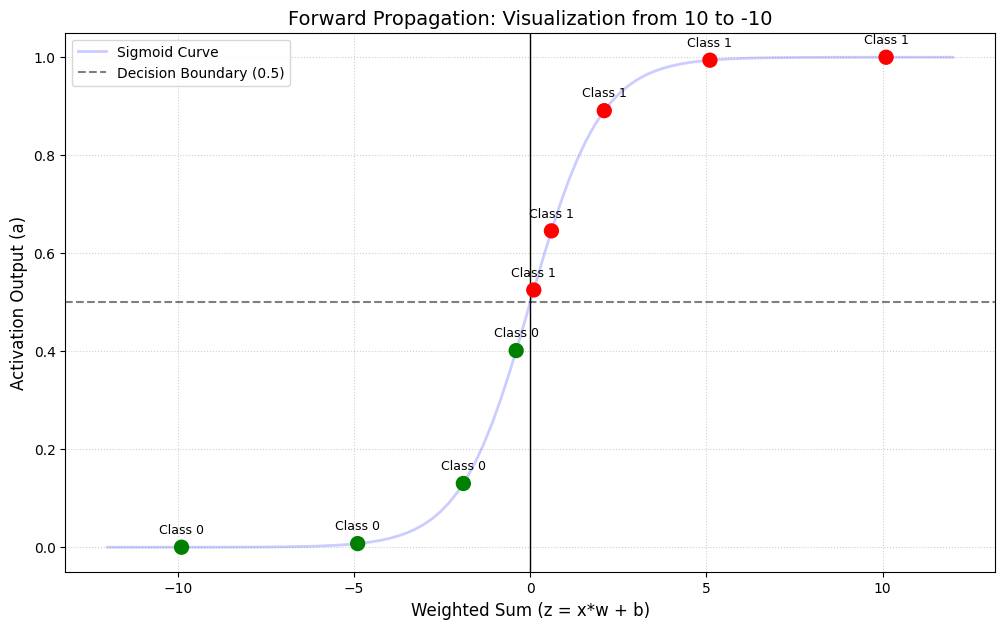

In [5]:
# Non-Linearity (Binary Classification)
df = np.array([10, 5, 2, 0.5, 0, -0.5, -2, -5, -10])
w = 1
b = 0.1

#Forward Propagation
z = df * w + b

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

a = sigmoid(z)

results = pd.DataFrame({
    'Input (x)': df,
    'Weighted Sum (z)': z,
    'Sigmoid (a)': a,
    'Predicted Class': [1 if i > 0.5 else 0 for i in a]
})

print("\t\t--- Forward Prop Results (Range: 10 to -10) ---")
print(results.round(4))

#Visualization
z_curve = np.linspace(-12, 12, 100) 
a_curve = sigmoid(z_curve)

plt.figure(figsize=(12, 7))

# Theoretical Sigmoid curve
plt.plot(z_curve, a_curve, color='blue', label='Sigmoid Curve', linewidth=2, alpha=0.2)

# Plotting specific 9 samples
plt.scatter(z, a, c=['red' if i > 0.5 else 'green' for i in a], s=100, zorder=5)

#Decision Boundary lines
plt.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='Decision Boundary (0.5)')
plt.axvline(x=0, color='black', linewidth=1)

# Annotate the points
for i, val in enumerate(z):
    label = f"Class {results['Predicted Class'][i]}"
    plt.annotate(label, (z[i], a[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

plt.title("Forward Propagation: Visualization from 10 to -10", fontsize=14)
plt.xlabel("Weighted Sum (z = x*w + b)", fontsize=12)
plt.ylabel("Activation Output (a)", fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [6]:
# Hidden Layer Dynamics (Matrix Multiplication)
import numpy as np
import pandas as pd

#1 sample with 2 features
X = np.array([[5.1, 3.5]]) 

#Weights for 2 inputs fanning out to 3 neurons
W = np.array([
    [0.1,  0.5, -0.2], 
    [0.4, -0.3,  0.8] 
])

#Baise value 1 for each of the 3 neurons
B = np.array([0.1, 0.2, -0.5])

Z = np.dot(X, W) + B

def relu(z):
    return np.maximum(0, z)

A = relu(Z)

hidden_layer_results = pd.DataFrame(
    A, 
    columns=['Neuron 1', 'Neuron 2', 'Neuron 3'],
    index=['Sample 1']
)

print("Weighted Sum (Z):", Z)
print("\nAfter ReLU Activation (A):")
print(hidden_layer_results)

Weighted Sum (Z): [[2.01 1.7  1.28]]

After ReLU Activation (A):
          Neuron 1  Neuron 2  Neuron 3
Sample 1      2.01       1.7      1.28


In [7]:
# Multiclass Output
def softmax(z):
    "Calculates the Softmax probability for each element in the array."
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z)

logits = np.array([2.0, 1.0, 0.1])
classes = ["Cat", "Dog", "Bird"]

#apply softmax
probabilities = softmax(logits)

#identify prediction
predicted_index = np.argmax(probabilities)
predicted_class = classes[predicted_index]

softmax_df = pd.DataFrame({
    'Class': classes,
    'Raw Score (z)': logits,
    'Probability (a)': probabilities
})

print("Softmax Results")
print(softmax_df.round(4))
print(f"\nFinal Prediction: {predicted_class} ({probabilities[predicted_index]*100:.2f}%)")

Softmax Results
  Class  Raw Score (z)  Probability (a)
0   Cat            2.0           0.6590
1   Dog            1.0           0.2424
2  Bird            0.1           0.0986

Final Prediction: Cat (65.90%)


In [8]:
#Dead Neurons relu vs leaky_relu
def relu(z):
    return np.maximum(0, z)

def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)

# neuron with a negative weighted sum
z_negative = -5.0

# 2. Calculate outputs
output_relu = relu(z_negative)
output_leaky = leaky_relu(z_negative)

# 3. Display Comparison
print("Activation Function Comparison")
print(f"Input (z): {z_negative}")
print(f"Standard ReLU Output:    {output_relu}  (The neuron is 'Dead')")
print(f"Leaky ReLU Output:       {output_leaky} (The neuron is 'Leaking' a signal)")

# 4. Visualizing the difference for a range of values
test_range = np.array([2.0, 1.0, 0.0, -1.0, -2.0])
print("\nRange:", test_range)
print(f"ReLU:       {relu(test_range)}")
print(f"Leaky ReLU: {leaky_relu(test_range)}")

Activation Function Comparison
Input (z): -5.0
Standard ReLU Output:    0.0  (The neuron is 'Dead')
Leaky ReLU Output:       -0.05 (The neuron is 'Leaking' a signal)

Range: [ 2.  1.  0. -1. -2.]
ReLU:       [2. 1. 0. 0. 0.]
Leaky ReLU: [ 2.    1.    0.   -0.01 -0.02]


In [ ]:
# BACKWARD PROPGATION

#scaled data
X = np.array([
    [0.6, 0.8, 0.8],   # Student A: Pass
    [0.4, 0.48, 0.4],  # Student B: Fail
    [0.88, 0.72, 0.9]  # Student C: Pass
])
y_true = np.array([1, 0, 1])

# Initial Weights and Bias
weights = np.array([0.5, 0.3, 0.8])
bias = -0.5
learning_rate = 0.1

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(yout):
    return yout * (1 - yout)

In [10]:
# Select Student B (index 1)
inputs = X[1]
target = y_true[1]

# Calculation
z = np.dot(inputs, weights) + bias
yout = sigmoid(z)
loss = 0.5 * (target - yout)**2

print(f"Forward Pass Output (Probability of Passing): {yout:.4f}")
print(f"Initial MSE Loss: {loss:.4f}")

Forward Pass Output (Probability of Passing): 0.5409
Initial MSE Loss: 0.1463


In [11]:
# Error Signal (delta) = (yout - target) * sigmoid_derivative
error = yout - target
delta = error * sigmoid_derivative(yout)

# Gradients for each weight
gradients = delta * inputs

print(f"Error Signal (delta): {delta:.4f}")
print(f"Gradients for Weights: {gradients}")

Error Signal (delta): 0.1343
Gradients for Weights: [0.05372875 0.0644745  0.05372875]


In [12]:
# Update weights and bias
weights = weights - (learning_rate * gradients)
bias = bias - (learning_rate * delta)

print(f"Updated Weights: {weights}")
print(f"Updated Bias: {bias:.4f}")

Updated Weights: [0.49462712 0.29355255 0.79462712]
Updated Bias: -0.5134


In [13]:
# Reset weights for training
w = np.array([0.5, 0.3, 0.8])
b = -0.5

print("\nStarting Training")
for epoch in range(1000):
    for i in range(len(X)):
        # 1. Forward Pass
        z = np.dot(X[i], w) + b
        pred = sigmoid(z)
        
        # 2. Backprop
        d_loss_d_pred = pred - y_true[i]
        d_pred_d_z = sigmoid_derivative(pred)
        delta = d_loss_d_pred * d_pred_d_z
        
        # 3. Update
        w -= learning_rate * delta * X[i]
        b -= learning_rate * delta

# Final Test on Student B
z_final = np.dot(X[1], w) + b
pred_final = sigmoid(z_final)
print(f"Final Prediction for Student B: {pred_final:.4f}")
print("Result: FAIL" if pred_final < 0.5 else "Result: PASS")


Starting Training
Final Prediction for Student B: 0.3259
Result: FAIL


In [ ]:
# Sentiment Analysis
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def binary_cross_entropy(y_true, y_pred):
    return -np.mean(
        y_true * np.log(y_pred + 1e-8) +
        (1 - y_true) * np.log(1 - y_pred + 1e-8)
    )

# DATASET (Simulated)

np.random.seed(42)

# 10 samples, 100 features 
X = np.random.rand(10, 100)

# Labels (1 = positive, 0 = negative)
y = np.array([[1],[0],[1],[1],[0],[0],[1],[0],[1],[0]])

# NETWORK ARCHITECTURE

input_size = 100
hidden1 = 64
hidden2 = 32
output_size = 1

# Weight initialization (small values = important)
W1 = np.random.randn(input_size, hidden1) * 0.01
W2 = np.random.randn(hidden1, hidden2) * 0.01
W3 = np.random.randn(hidden2, output_size) * 0.01

# Learning rate
lr = 0.01

# TRAINING LOOP

epochs = 1000

for epoch in range(epochs):

    #  Forward Propagation 
    z1 = np.dot(X, W1)
    a1 = relu(z1)

    z2 = np.dot(a1, W2)
    a2 = relu(z2)

    z3 = np.dot(a2, W3)
    y_pred = sigmoid(z3)

    #  Loss 
    loss = binary_cross_entropy(y, y_pred)

    #  Backpropagation 
    d_y_pred = y_pred - y

    dW3 = np.dot(a2.T, d_y_pred)

    d_a2 = np.dot(d_y_pred, W3.T)
    d_z2 = d_a2 * relu_derivative(z2)
    dW2 = np.dot(a1.T, d_z2)

    d_a1 = np.dot(d_z2, W2.T)
    d_z1 = d_a1 * relu_derivative(z1)
    dW1 = np.dot(X.T, d_z1)

    #  Update Weights 
    W3 -= lr * dW3
    W2 -= lr * dW2
    W1 -= lr * dW1

    # Print progress
    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss}")

# FINAL PREDICTIONS

print("\nFinal Predictions:\n", y_pred)

# Convert to class labels
predictions = (y_pred > 0.5).astype(int)
print("\nClass Labels:\n", predictions)

Epoch 0, Loss: 0.6931481005959677
Epoch 200, Loss: 0.6930083490604606
Epoch 400, Loss: 0.6914657080109535
Epoch 600, Loss: 0.03468389516405288
Epoch 800, Loss: 0.0022657259678639102

Final Predictions:
 [[0.99912667]
 [0.00132144]
 [0.99930746]
 [0.99882407]
 [0.00111472]
 [0.00102361]
 [0.99874041]
 [0.00102613]
 [0.99966068]
 [0.00107662]]

Class Labels:
 [[1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]]


In [15]:
# past 5 days’ stock prices
import numpy as np


def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# DATA (Normalized)

np.random.seed(42)

X = np.random.rand(10, 5)
y = np.random.rand(10, 1)

# NETWORK

W1 = np.random.randn(5, 16) * 0.1
W2 = np.random.randn(16, 8) * 0.1
W3 = np.random.randn(8, 1) * 0.1

lr = 0.01  

# TRAINING

for epoch in range(1000):

    # Forward
    z1 = np.dot(X, W1)
    a1 = relu(z1)

    z2 = np.dot(a1, W2)
    a2 = relu(z2)

    y_pred = np.dot(a2, W3)

    loss = mse(y, y_pred)

    # Backprop
    d_out = (y_pred - y)

    dW3 = a2.T.dot(d_out)

    d_a2 = d_out.dot(W3.T)
    d_z2 = d_a2 * relu_derivative(z2)
    dW2 = a1.T.dot(d_z2)

    d_a1 = d_z2.dot(W2.T)
    d_z1 = d_a1 * relu_derivative(z1)
    dW1 = X.T.dot(d_z1)

    # Update
    W3 -= lr * dW3
    W2 -= lr * dW2
    W1 -= lr * dW1

    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss}")

print("\nFinal Predictions:\n", y_pred)

Epoch 0, Loss: 0.4593830478403221
Epoch 200, Loss: 0.03724183983641175
Epoch 400, Loss: 0.0324354121112434
Epoch 600, Loss: 0.03207588180365598
Epoch 800, Loss: 0.03189573743123926

Final Predictions:
 [[0.93138926]
 [0.87844827]
 [0.98965194]
 [0.59400612]
 [0.43023603]
 [0.73103307]
 [0.08934824]
 [0.26075415]
 [0.05002803]
 [0.70391161]]


In [16]:
#movie rating system
import numpy as np

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# SYNTHETIC DATASET

np.random.seed(42)

# 10 users × movies samples
# User features = 10, Movie features = 20
user_features = np.random.rand(10, 10)
movie_features = np.random.rand(10, 20)

# Combine user + movie features → input size = 30
X = np.concatenate([user_features, movie_features], axis=1)

# Ratings (1–5 scale)
y = np.random.rand(10, 1) * 5

# NEURAL NETWORK ARCHITECTURE

input_size = 30
h1 = 64
h2 = 32
output_size = 1

# Weight initialization (small random values)
W1 = np.random.randn(input_size, h1) * 0.01
W2 = np.random.randn(h1, h2) * 0.01
W3 = np.random.randn(h2, output_size) * 0.01

lr = 0.01

# TRAINING LOOP

epochs = 1000

for epoch in range(epochs):

    # Forward Propagation 
    z1 = np.dot(X, W1)
    a1 = relu(z1)

    z2 = np.dot(a1, W2)
    a2 = relu(z2)

    y_pred = np.dot(a2, W3)  # Linear output for regression

    #  Loss 
    loss = mse(y, y_pred)

    #  Backpropagation 
    d_out = (y_pred - y)

    dW3 = np.dot(a2.T, d_out)

    d_a2 = np.dot(d_out, W3.T)
    d_z2 = d_a2 * relu_derivative(z2)
    dW2 = np.dot(a1.T, d_z2)

    d_a1 = np.dot(d_z2, W2.T)
    d_z1 = d_a1 * relu_derivative(z1)
    dW1 = np.dot(X.T, d_z1)

    # Update Weights 
    W3 -= lr * dW3
    W2 -= lr * dW2
    W1 -= lr * dW1

    # Print progress
    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss}")

print("\nFinal Predicted Ratings (1–5 scale):\n", y_pred)

Epoch 0, Loss: 8.84892303447033
Epoch 200, Loss: 0.565378242644637
Epoch 400, Loss: 0.5054000477440677
Epoch 600, Loss: 0.49309531626935976
Epoch 800, Loss: 0.4900334341107403

Final Predicted Ratings (1–5 scale):
 [[0.03289193]
 [1.65033778]
 [1.68725534]
 [2.04129391]
 [2.32498642]
 [3.28020242]
 [1.60641888]
 [0.81396584]
 [2.51795832]
 [0.70836694]]


In [17]:
# Disease Prediction using Deep Neural Network
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def bce(y, y_hat):
    return -np.mean(y*np.log(y_hat+1e-8) + (1-y)*np.log(1-y_hat+1e-8))

# binary classification neural network

np.random.seed(42)

X = np.random.rand(100, 15)

y = ((X[:, 0] + X[:, 1] + X[:, 2]) > 1.5).astype(int).reshape(-1, 1)

# NETWORK

W1 = np.random.randn(15, 32) * 0.1
W2 = np.random.randn(32, 16) * 0.1
W3 = np.random.randn(16, 1) * 0.1

lr = 0.01

# TRAINING
for epoch in range(1000):

    # forward
    z1 = X @ W1
    a1 = relu(z1)

    z2 = a1 @ W2
    a2 = relu(z2)

    z3 = a2 @ W3
    y_pred = sigmoid(z3)

    loss = bce(y, y_pred)

    # backprop
    d3 = y_pred - y
    dW3 = a2.T @ d3

    d2 = (d3 @ W3.T) * relu_derivative(z2)
    dW2 = a1.T @ d2

    d1 = (d2 @ W2.T) * relu_derivative(z1)
    dW1 = X.T @ d1

    # update
    W3 -= lr * dW3
    W2 -= lr * dW2
    W1 -= lr * dW1

    if epoch % 200 == 0:
        print("Epoch", epoch, "Loss:", loss)

print("\nPredictions:\n", y_pred)
print("\nClasses:\n", (y_pred > 0.5).astype(int))

Epoch 0 Loss: 0.693096971113639
Epoch 200 Loss: 0.23882624737553568
Epoch 400 Loss: 0.4222808377050755
Epoch 600 Loss: 0.35579154703889265
Epoch 800 Loss: 0.0448673759834655

Predictions:
 [[9.99999963e-01]
 [1.50378269e-04]
 [2.18126965e-09]
 [1.32866832e-03]
 [1.44401017e-05]
 [9.99995335e-01]
 [9.77105920e-01]
 [4.50261754e-03]
 [9.99998667e-01]
 [9.83848993e-01]
 [7.34909531e-11]
 [1.75167535e-03]
 [2.35053497e-02]
 [1.00000000e+00]
 [9.99995929e-01]
 [9.99760069e-01]
 [1.00000000e+00]
 [9.99999899e-01]
 [9.99999994e-01]
 [6.61994127e-04]
 [1.68033255e-06]
 [6.85813841e-07]
 [5.55490070e-04]
 [2.26004345e-08]
 [8.31075371e-03]
 [1.04136996e-11]
 [9.99999600e-01]
 [7.20548262e-14]
 [9.99999318e-01]
 [9.49541010e-01]
 [9.99999991e-01]
 [9.99995512e-01]
 [9.99256792e-01]
 [3.86237118e-15]
 [1.00000000e+00]
 [9.77472579e-16]
 [9.99711532e-01]
 [1.24574227e-13]
 [5.00000000e-01]
 [1.15120648e-10]
 [1.22029792e-07]
 [1.86381731e-03]
 [1.00000000e+00]
 [1.00000000e+00]
 [1.00000000e+00]
 

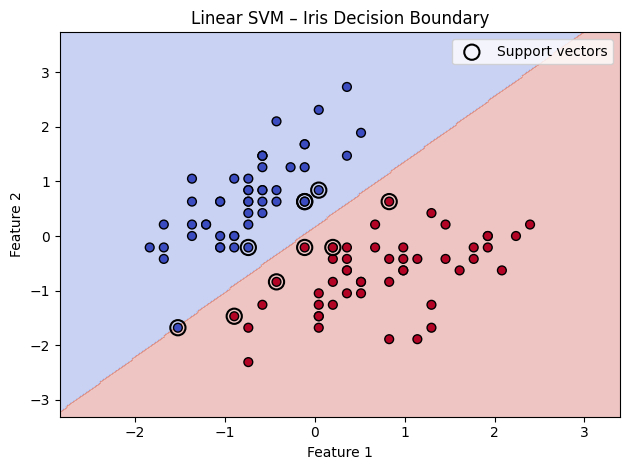

No. of support vectors: 10


In [18]:
# Q1: Linear SVM – Decision Boundary on Iris
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

iris = datasets.load_iris()
X = iris.data[:100, :2]   # 2 features, 2 classes
y = iris.target[:100]

sc = StandardScaler()
X = sc.fit_transform(X)

model = SVC(kernel='linear', C=1.0)
model.fit(X, y)

xx, yy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
                     np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolors='k', s=40)
sv = model.support_vectors_
plt.scatter(sv[:,0], sv[:,1], s=120, facecolors='none',
            edgecolors='black', linewidths=1.5, label='Support vectors')
plt.legend(); plt.title('Linear SVM – Iris Decision Boundary')
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.tight_layout(); plt.show()
print(f"No. of support vectors: {model.support_vectors_.shape[0]}")

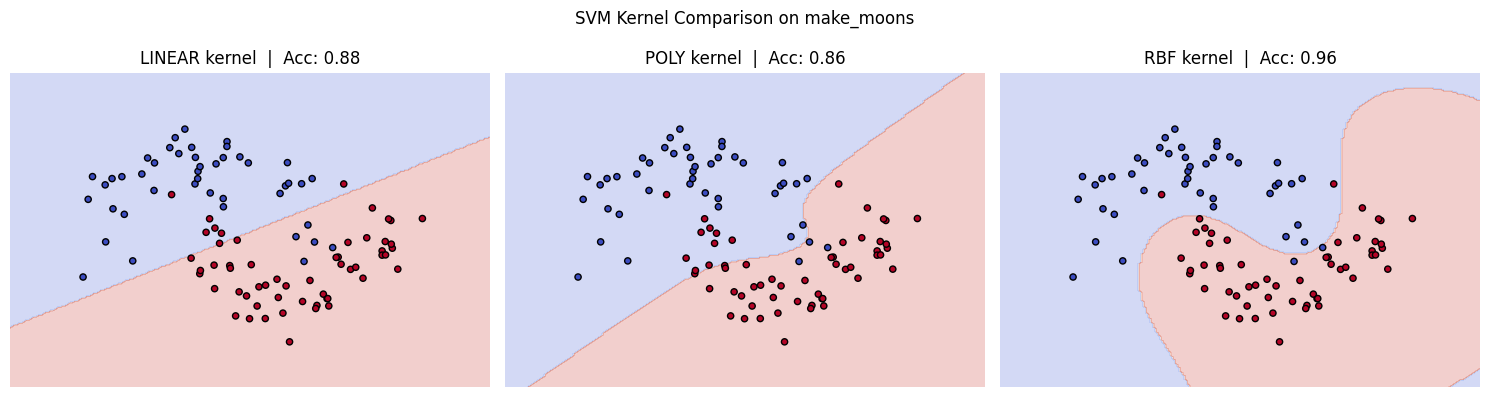

In [19]:
# Q2: Kernel Comparison – Linear vs Poly vs RBF
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = make_moons(n_samples=400, noise=0.25, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25)
sc = StandardScaler(); X_tr=sc.fit_transform(X_tr); X_te=sc.transform(X_te)

kernels = ['linear', 'poly', 'rbf']
colors  = ['#534AB7', '#0F6E56', '#185FA5']
fig, axes = plt.subplots(1, 3, figsize=(15,4))

for ax, k, col in zip(axes, kernels, colors):
    clf = SVC(kernel=k, degree=3).fit(X_tr, y_tr)
    acc = clf.score(X_te, y_te)
    xx,yy = np.meshgrid(np.linspace(-3,3,200), np.linspace(-3,3,200))
    Z = clf.predict(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx,yy,Z,alpha=0.25,cmap='coolwarm')
    ax.scatter(X_te[:,0],X_te[:,1],c=y_te,cmap='coolwarm',edgecolors='k',s=20)
    ax.set_title(f"{k.upper()} kernel  |  Acc: {acc:.2f}")
    ax.axis('off')

plt.suptitle('SVM Kernel Comparison on make_moons')
plt.tight_layout(); plt.show()

In [20]:
# Q3: Hyperparameter Tuning – GridSearchCV Heatmap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

X, y = load_breast_cancer(return_X_y=True)
sc = StandardScaler(); X = sc.fit_transform(X)

param_grid = {
    'C':     [0.01, 0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1, 10]
}
gs = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=5, n_jobs=-1)
gs.fit(X, y)

scores = gs.cv_results_['mean_test_score'].reshape(5,5)
plt.figure(figsize=(7,5))
sns.heatmap(scores, annot=True, fmt='.3f', cmap='YlGnBu',
            xticklabels=param_grid['gamma'],
            yticklabels=param_grid['C'])
plt.xlabel('Gamma'); plt.ylabel('C')
plt.title('GridSearchCV Accuracy: C vs Gamma (RBF SVM)')
plt.tight_layout(); plt.show()
print(f"Best params : {gs.best_params_}")
print(f"Best CV acc : {gs.best_score_:.4f}")

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
# Q4: Multi-class SVM – Digits Dataset
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

digits = load_digits()
X, y = digits.data, digits.target
X_tr,X_te,y_tr,y_te = train_test_split(X, y, test_size=0.2, random_state=42)
sc = StandardScaler(); X_tr=sc.fit_transform(X_tr); X_te=sc.transform(X_te)

model = SVC(kernel='rbf', C=10, gamma='scale')
model.fit(X_tr, y_tr); pred = model.predict(X_te)

print(classification_report(y_te, pred))
cm = confusion_matrix(y_te, pred)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title(f'SVM Confusion Matrix – Digits  (Acc: {model.score(X_te,y_te):.3f})')
plt.tight_layout(); plt.show()


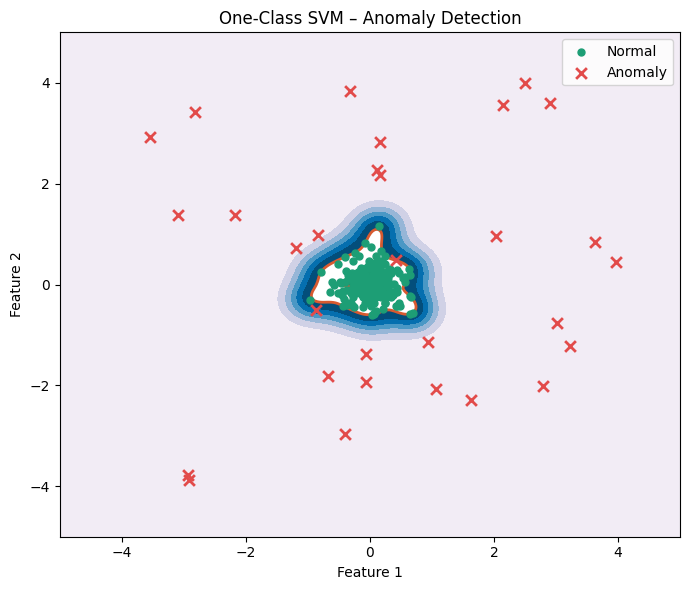

Anomalies detected: 30 / 30


In [1]:
# Q5: One-Class SVM – Anomaly Detection
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import OneClassSVM

np.random.seed(42)
# Normal data: tight cluster
X_normal  = 0.3 * np.random.randn(200, 2)
# Anomalies: scattered far away
X_anomaly = np.random.uniform(low=-4, high=4, size=(30, 2))

model = OneClassSVM(kernel='rbf', nu=0.05, gamma='scale')
model.fit(X_normal)

xx,yy = np.meshgrid(np.linspace(-5,5,300), np.linspace(-5,5,300))
Z = model.decision_function(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7,6))
plt.contourf(xx, yy, Z, levels=np.linspace(Z.min(),0,7), cmap='PuBu')
plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='#D85A30')
plt.scatter(X_normal[:,0],  X_normal[:,1],  c='#1D9E75', s=25, label='Normal',  zorder=3)
plt.scatter(X_anomaly[:,0], X_anomaly[:,1], c='#E24B4A', s=60, marker='x',
            linewidths=2, label='Anomaly', zorder=3)
plt.legend(); plt.title('One-Class SVM – Anomaly Detection')
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.tight_layout(); plt.show()

preds = model.predict(X_anomaly)
detected = np.sum(preds == -1)
print(f"Anomalies detected: {detected} / {len(X_anomaly)}")